In [ ]:
library(hdf5r)
library(Seurat)
library(ggplot2)
library(stringr)
#####feature plot
library(Seurat)
library(ggplot2)
library(cowplot)
library(dplyr)
library(tidyr)
library(stringr)
library(viridis)
library(reshape2)
library(patchwork)
library(ggplot2)
library(ggridges)
library(RColorBrewer)
library(scales)
library("circlize")
library(ComplexHeatmap)

In [4]:
setwd("./07S3_update/")

In [5]:
sp <- readRDS("merge_sp.RDS")

In [6]:
Idents(sp) <- as.factor(sp@meta.data$ann2)
sp <- NormalizeData(sp)
sp1 <- subset(x = sp,downsample = 2000)

Normalizing layer: counts



In [13]:
sp@meta.data$ann2 <- str_replace(sp@meta.data$ann2,"EC_1","iEC")
sp@meta.data$ann2 <- str_replace(sp@meta.data$ann2,"EC_2","vEC")

In [17]:
unique(sp@meta.data$ann2)
sp@meta.data$ann2 <- factor(sp@meta.data$ann2,levels = c('Fib','SMC','mSMC','Monocyte','Macro','DC','Mast_cell','B_cell','plasma cell','NKT','iEC','vEC'))
cell <- c('Fib','SMC','mSMC','Monocyte','Macro','DC','Mast_cell','B_cell','plasma cell','NKT','iEC','vEC')
cols2 <- c('Fib'="#8b4a4b",'SMC'="#1f78b4",'mSMC'="#A1CFFA",'Monocyte'="#E9B3FB",'Macro'="#df65b0",'DC'="#A5158C",'Mast_cell'="#FA26A0",'B_cell'="#EF7722",'plasma cell'="#FCB53B",'NKT'="#ce1256",'iEC'="#238b45",'vEC'="#06D001")

[1] SMC         mSMC        Fib         DC          iEC         vEC        
 [7] B_cell      Macro       Monocyte    Mast_cell   NKT         plasma cell
12 Levels: Fib SMC mSMC Monocyte Macro DC Mast_cell B_cell plasma cell ... vEC

In [20]:
gene <- c("APOD","DCN","PI16","CFD","SERPINF1","IGFBP6",###Fib
          "ACTA2","MYH11","MYL9","TAGLN","FLNA",###SMC
          "LUM","FN1","VCAN","BGN",#mSMC
          "CSF3R","PHACTR1","FCN1","APOBEC3A","C5AR1",##Monocyte
          'SPP1','CTSB','CTSD','APOC1',"APOE","LYZ",##Macro
          "CD163","MRC1","HLA-DRA","LYVE1",##DC
          "KIT","HDC","HPGD","HPGDS","TPSB2",##Mast_cell
          "BANK1","CD83","IGHM","IGHA1","JCHAIN","IGKC",####B_cell
          "IGHG1","IGHG2","IGHG4","IGHA2",###plasma 
          "CD247","GNLY","CCL5","IL7R","KLRD1",###NKT  
          "ACKR1","EMCN","SOX18","VWF","PECAM1","CLDN5",###iEC
          "DKK2","SELP","BMX"###vEC      
         )

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.


[1] SMC         mSMC        Fib         DC          iEC         vEC        
 [7] B_cell      Macro       Monocyte    Mast_cell   NKT         plasma cell
12 Levels: Fib SMC mSMC Monocyte Macro DC Mast_cell B_cell plasma cell ... vEC

[1] "RNA.Fib"         "RNA.SMC"         "RNA.mSMC"        "RNA.Monocyte"   
 [5] "RNA.Macro"       "RNA.DC"          "RNA.Mast.cell"   "RNA.B.cell"     
 [9] "RNA.plasma.cell" "RNA.NKT"         "RNA.iEC"         "RNA.vEC"

[1] "Fib"         "SMC"         "mSMC"        "Monocyte"    "Macro"      
 [6] "DC"          "Mast_cell"   "B_cell"      "plasma cell" "NKT"        
[11] "iEC"         "vEC"

pdf 
  2

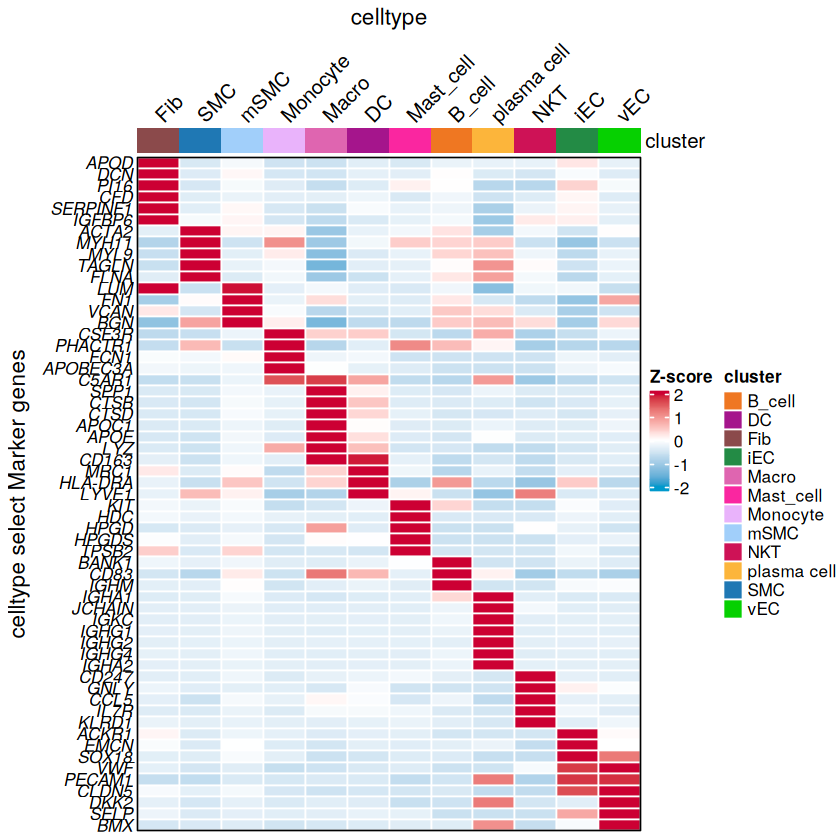

In [21]:
####heatmap plot 
mean_gene_exp<-AverageExpression(sp,features=gene,group.by='ann2',slot='data')%>%data.frame()%>%as.matrix()
unique(sp@meta.data$ann2)
colnames(mean_gene_exp)
colnames(mean_gene_exp) <- cell
colnames(mean_gene_exp)
m <- t(subset(as.data.frame(t(mean_gene_exp)),select = gene))
# Z-score
htdf <- t(scale(t(m),scale = T,center = T))

# color
col_fun = colorRamp2(c(-2, 0, 2), c("#0099CC", "white", "#CC0033"))

# top annotation
column_ha = HeatmapAnnotation(cluster = colnames(htdf),col = list(cluster = cols2))
# plot
p <- Heatmap(htdf,
        name = "Z-score",
        cluster_columns = F,cluster_rows = F,
        row_title = "celltype select Marker genes",
        column_title = "celltype",
        row_names_gp = gpar(fontface = 'italic',fontsize = 10),
        row_names_side = 'left',
        border = T,
        rect_gp = gpar(col = "white", lwd = 1),
        column_names_side = 'top',
        column_names_rot = 45,
        top_annotation = column_ha,
        # column_split = paste('clsuter ',0:8,sep = ''),
        col = col_fun)
p
pdf("S3_hs_st_gene_heatmap.pdf",width = 6.5,height = 10)
print(p)
dev.off()